# Naive Bayes Classification on Car Evaluation Dataset

This notebook applies the Naive Bayes algorithm to classify car acceptability based on various features.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and Explore the Data

In [9]:
# Load dataset
df = pd.read_csv('car_evaluation.csv', header=None)
df.columns = ['Price', 'Maintenance', 'Doors', 'Persons', 'Lug_boot', 'Safety', 'Class']
print(df.head())

print(f"Shape: {df.shape}")
print(f"Classes:\n{df['Class'].value_counts()}")

   Price Maintenance Doors Persons Lug_boot Safety  Class
0  vhigh       vhigh     2       2    small    low  unacc
1  vhigh       vhigh     2       2    small    med  unacc
2  vhigh       vhigh     2       2    small   high  unacc
3  vhigh       vhigh     2       2      med    low  unacc
4  vhigh       vhigh     2       2      med    med  unacc
Shape: (1728, 7)
Classes:
Class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


## 2. Data Preparation and Encoding

In [4]:
# Encode categorical features
df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])

X = df_encoded.iloc[:, :-1]
y = df_encoded.iloc[:, -1]

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")

Features: 6, Samples: 1728


## 3. Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1382, Test: 346


## 4. Train Naive Bayes Model

In [6]:
model = GaussianNB()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## 5. Model Evaluation and Performance Metrics

In [7]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Naive Bayes Results")
print("=" * 40)
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Naive Bayes Results
Train Accuracy: 0.6397
Test Accuracy:  0.6416

Confusion Matrix:
[[  5   0  33  39]
 [  2   0   7   5]
 [  2   0 204  36]
 [  0   0   0  13]]


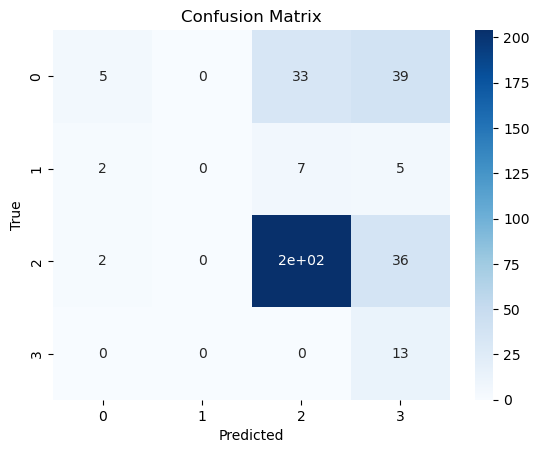

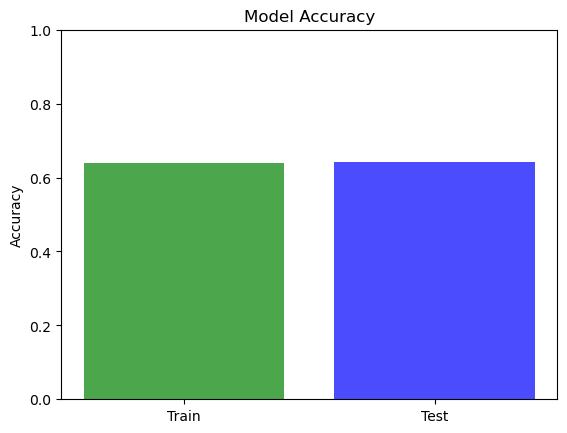

In [8]:
# Plots
cm = confusion_matrix(y_test, y_test_pred)
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion Matrix
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()
# Accuracy Comparison
metrics = ['Train', 'Test']
accs = [train_acc, test_acc]
plt.bar(metrics, accs, color=['green', 'blue'], alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.ylim([0, 1])

plt.show()